In [15]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt
from quantumScarFunctions import *

In [16]:
wm = 1.0
wd = 0.6365091993031
tlist = np.linspace(0, 200, 400)

A = 1.0
disorder = 0.1
reals = 300
N = 8

In [17]:
H0, eigenvalues, eigenstates, psi0, basisList = get_scar_ham(N)
H1_list, driveWeights = get_scar_H1(N, basisList, indv_qubit=True)

bandwidth = eigenvalues[-1] - eigenvalues[0]
psi_init = eigenstates[0]

Rtau_scar = []
for _ in range(reals):
    omega_list = wd + np.random.uniform(-disorder, disorder, N)

    args = {"A": A}
    H = [H0]
    for r in range(N):
        args[f"wd{r}"] = omega_list[r]
        H.append([H1_list[r], make_coeff(r)])

    H = qt.QobjEvo(H, args=args)
    psi_t = qt.sesolve(H, psi_init, tlist, e_ops=[H0])
    Rtau_scar.append(np.real(psi_t.expect[0] - psi_t.expect[0][0]) / bandwidth)

Rtau_scar = np.array(Rtau_scar)
scar_mean = Rtau_scar.mean(axis=0)
scar_sem = Rtau_scar.std(axis=0, ddof=1) / np.sqrt(reals)

In [18]:
qH0_list, qH1_list, qDriveWeights = get_qubit_ham(N, wm=wm)

# qH0 has no disorder here, so spectra are realization-independent -> hoist out
q_eigs = [qH0.eigenstates() for qH0 in qH0_list]
bw_tot = sum(ev[-1] - ev[0] for ev, _ in q_eigs)

Rtau_qubit = []
for _ in range(reals):
    omega_list = wm + np.random.uniform(-disorder, disorder, N)

    dE_tot = np.zeros(len(tlist))
    for r in range(N):
        qeigenvalues, qeigenstates = q_eigs[r]

        qH = qt.QobjEvo([qH0_list[r], [qH1_list[r], coeff]],
                        args={"A": A, "omega": omega_list[r]})
        qpsi_t = qt.sesolve(qH, qeigenstates[0], tlist, e_ops=[qH0_list[r]])
        dE_tot += np.real(qpsi_t.expect[0] - qpsi_t.expect[0][0])

    Rtau_qubit.append(dE_tot / bw_tot)

Rtau_qubit = np.array(Rtau_qubit)
qubit_mean = Rtau_qubit.mean(axis=0)
qubit_sem = Rtau_qubit.std(axis=0, ddof=1) / np.sqrt(reals)

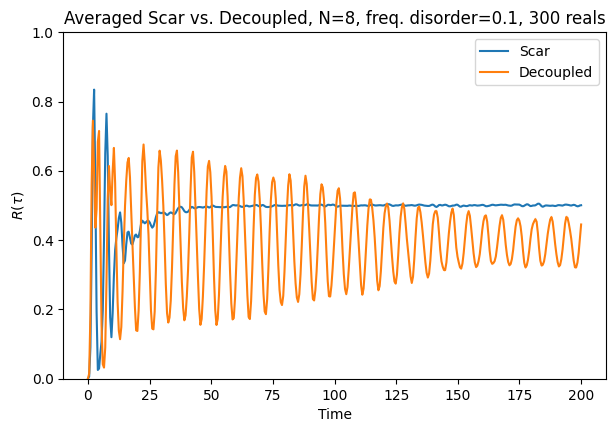

scar  max = 0.8343
qubit max = 0.7449


In [ ]:
fig, ax = plt.subplots(figsize=(7, 4.5))

ax.plot(tlist, scar_mean, label="Scar")
ax.fill_between(tlist, scar_mean - scar_sem, scar_mean + scar_sem, alpha=0.25, lw=0)

ax.plot(tlist, qubit_mean, label="Decoupled")
ax.fill_between(tlist, qubit_mean - qubit_sem, qubit_mean + qubit_sem, alpha=0.25, lw=0)

ax.set_title(f"Averaged Scar vs. Decoupled, N={N}, freq. disorder={disorder}, {reals} reals")
ax.set_xlabel("Time")
ax.set_ylabel(r"$R(\tau)$")
ax.set_ylim(0, 1)
ax.legend()

plt.savefig(f"figures/freq_N{N}_dis{disorder}_reals{reals}.pdf")
plt.show()

print(f"scar  max = {scar_mean.max():.4f}")
print(f"qubit max = {qubit_mean.max():.4f}")